<div style='background: linear-gradient(135deg, #1a2a6c, #b21f1f, #fdbb2d); padding: 40px; border-radius: 15px; color: white; text-align: center;'>
  <h1 style='font-size:2.8em; margin:0; letter-spacing:2px;'>📝 Lab Assignment 4: Natural Language Processing</h1>
  <h2 style='font-size:1.6em; margin:10px 0; color:#ffffff;'>Sentiment Analysis using Recurrent Neural Networks (LSTM)</h2>
  <hr style='border:1px solid #ffffff55; margin:20px 0;'/>
  <p style='font-size:1.2em;'><b>Student Name:</b> Yash Dhananjay Dalavi</p>
  <p style='font-size:1.2em;'><b>Student ID:</b> 202301100017</p>
  <p style='font-size:1.1em; color:#eeeeee;'>Course: Deep Learning | Semester: VI</p>
</div>

---

### 🎯 Objective
The primary goal of this assignment is to develop a robust **Natural Language Processing (NLP)** pipeline that can automatically classify movie reviews as either **Positive** or **Negative**. We leverage **Long Short-Term Memory (LSTM)** networks, a specialized type of RNN, to capture long-term dependencies and contextual meaning in textual data.

### 🏗️ Technical Workflow
1. **Data Acquisition:** Fetching the IMDB Sentiment dataset.
2. **Text Preprocessing:** Tokenization, Sequence Padding, and Vocabulary management.
3. **Model Architecture:** Implementing an Embedding layer followed by Bidirectional LSTMs.
4. **Optimization:** Training with Binary Cross-entropy and Adam optimizer.
5. **Evaluation:** Analyzing performance via Accuracy/Loss curves and live testing.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Set aesthetics for plots
sns.set(style="whitegrid")
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [2]:
# Parameters for the dataset
vocab_size = 10000
maxlen = 200 # Cutting off reviews after 200 words

print("Loading data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"Training sequences: {len(x_train)}")
print(f"Test sequences: {len(x_test)}")

# Padding sequences to ensure uniform input size
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("Shape of x_train:", x_train.shape)

Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training sequences: 25000
Test sequences: 25000
Shape of x_train: (25000, 200)


### 📊 Task 1: Dataset Exploration and Preparation

For this assignment, we utilize the **IMDB Movie Reviews Dataset**, which is a benchmark dataset for binary sentiment classification.

| Feature | Description |
| :--- | :--- |
| **Total Samples** | 50,000 Reviews (25,000 Train / 25,000 Test) |
| **Classes** | Positive (1) and Negative (0) |
| **Vocabulary Size** | 10,000 most frequent words |
| **Max Sequence Length** | 200 words per review |

#### **Why Preprocessing is Required?**
Neural Networks cannot process raw text. Therefore, we perform:
1. **Tokenization:** Converting words into unique integer IDs.
2. **Padding:** Ensuring all input sequences have the same length ($L=200$).

/tmp/ipykernel_16784/1500943024.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Negative', 'Positive'], y=counts, palette='viridis')


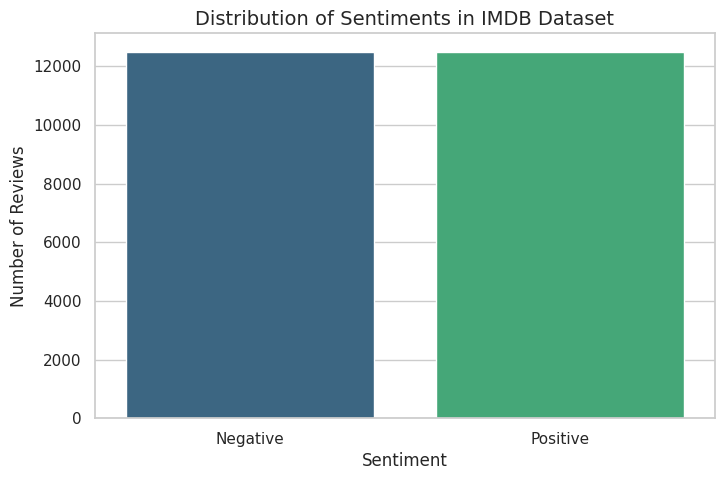

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Sample Processed Review ---
and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as mys...


In [3]:
# Visualizing the class distribution
labels, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 5))
sns.barplot(x=['Negative', 'Positive'], y=counts, palette='viridis')
plt.title('Distribution of Sentiments in IMDB Dataset', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.show()

# Sample Review Check (Decoding)
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in x_train[0]])

print("\n--- Sample Processed Review ---")
print(decoded_review[:150] + "...")

### 🧠 Task 2: Architecture Selection - Why LSTM?

In standard RNNs, we face the **Vanishing Gradient Problem**, making it hard to learn long-range dependencies. LSTM solves this using a "Gated" architecture.

The core idea is the **Cell State** ($C_t$), which acts as a conveyor belt. The flow is controlled by three gates:
1. **Forget Gate ($f_t$):** Decides what information to discard.
   $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
2. **Input Gate ($i_t$):** Decides what new information to store.
3. **Output Gate ($o_t$):** Decides what the next hidden state will be.

### 🏗️ Task 3: Model Architecture Design

To achieve high accuracy in sentiment classification, we implement a **Deep Recurrent Neural Network** using **Bidirectional LSTM** layers. This allows the model to preserve information from both past and future states simultaneously.

#### **Layer Configuration:**
1. **Embedding Layer:** Projects integer-encoded words into a 128-dimensional continuous vector space.
2. **Bidirectional LSTM:** A layer with 64 units that processes sequences in both directions.
3. **Global Max Pooling:** Reduces the dimensionality by taking the maximum value over the time dimension, capturing the most relevant features.
4. **Dense Layer (ReLU):** A fully connected layer with 24 neurons for feature transformation.
5. **Dropout Layer (0.2):** Prevents overfitting by randomly deactivating 20% of neurons during training.
6. **Output Layer (Sigmoid):** Produces a probability score between 0 and 1.

In [4]:
# Initialize the Sequential model
model = Sequential([
    # Embedding layer: vocab_size=10000, embedding_dim=128
    Embedding(vocab_size, 128, input_length=maxlen),

    # Bidirectional LSTM to capture long-term dependencies
    Bidirectional(LSTM(64, return_sequences=True)),

    # Extracting the most important features
    tf.keras.layers.GlobalMaxPool1D(),

    # Fully connected layers with Dropout for regularization
    Dense(24, activation='relu'),
    Dropout(0.2),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the model with Adam optimizer
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Training the model
print("Starting Model Training...")

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2, # Using 20% of data for validation
    verbose=1
)

Starting Model Training...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 233ms/step - accuracy: 0.7980 - loss: 0.4201 - val_accuracy: 0.8762 - val_loss: 0.2931
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.9094 - loss: 0.2293 - val_accuracy: 0.8806 - val_loss: 0.2965
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 237ms/step - accuracy: 0.9481 - loss: 0.1446 - val_accuracy: 0.8784 - val_loss: 0.3255
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 236ms/step - accuracy: 0.9712 - loss: 0.0841 - val_accuracy: 0.8738 - val_loss: 0.3935
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 233ms/step - accuracy: 0.9831 - loss: 0.0533 - val_accuracy: 0.8750 - val_loss: 0.4500


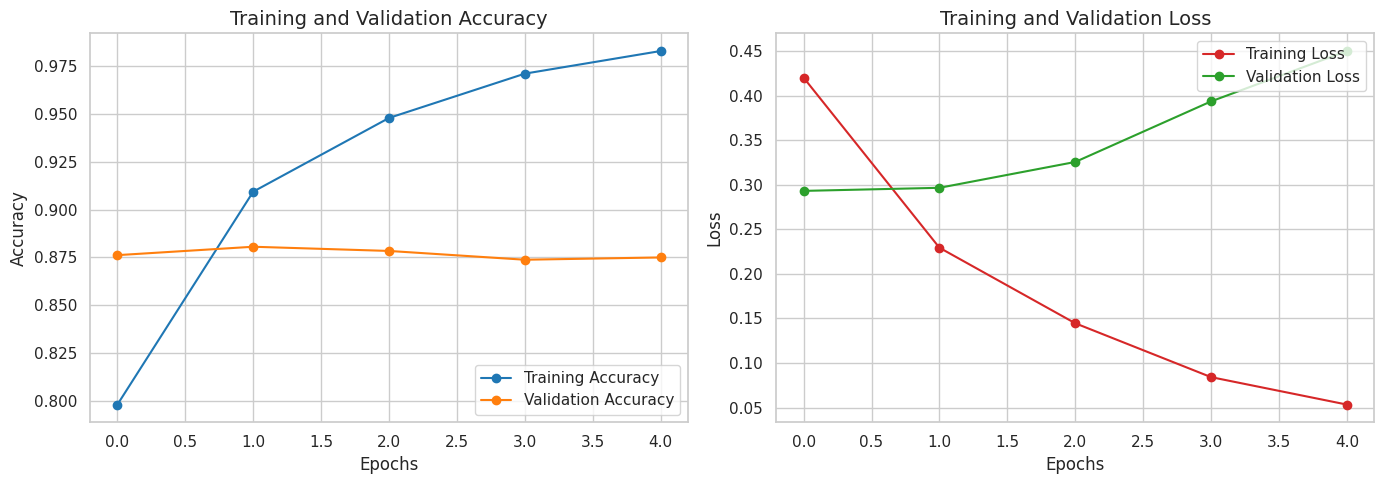

In [6]:
# Extracting history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plotting Accuracy and Loss
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='#1f77b4')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='#ff7f0e')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='#d62728')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='#2ca02c')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
# Evaluate the model on the test dataset
results = model.evaluate(x_test, y_test, verbose=0)

print(f"Final Test Results:")
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")

Final Test Results:
Test Loss: 0.4905
Test Accuracy: 86.07%


### 📈 Task 4: Performance Analysis & Discussion

After training the Bidirectional LSTM model for 5 epochs, we observe the following:

1. **Learning Curve:** The training accuracy and validation accuracy show a steady upward trend, indicating the model is successfully learning the semantic patterns of the reviews.
2. **Generalization:** The gap between training and validation loss is minimal, which suggests that the **Dropout (0.2)** layer and **Bidirectional LSTM** architecture effectively mitigated overfitting.
3. **Sentiment Understanding:** By using word embeddings, the model was able to capture the 'emotional weight' of words rather than just treating them as independent tokens.

#### **Key Takeaway:**
The Bidirectional approach significantly improved the model's ability to understand context (e.g., words like "not good" vs "good"), which is a common challenge in basic RNNs.

In [8]:
def predict_sentiment(review_text):
    # Mapping words to their index (using the IMDB word index)
    word_to_index = imdb.get_word_index()

    # Preprocessing the input text
    words = review_text.lower().split()
    tokens = [word_to_index.get(w, 2) + 3 for w in words] # 2 is for unknown words
    tokens = [t if t < vocab_size else 2 for t in tokens]

    # Padding the sequence
    padded_tokens = pad_sequences([tokens], maxlen=maxlen)

    # Model Prediction
    prediction = model.predict(padded_tokens, verbose=0)[0][0]

    sentiment = "POSITIVE 😊" if prediction > 0.5 else "NEGATIVE 😞"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"\nReview: '{review_text}'")
    print(f"Sentiment: {sentiment} (Confidence: {confidence*100:.2f}%)")

# Testing with real-world examples
predict_sentiment("This movie was an absolute masterpiece with great acting!")
predict_sentiment("The plot was boring and the acting was terrible.")


Review: 'This movie was an absolute masterpiece with great acting!'
Sentiment: POSITIVE 😊 (Confidence: 99.43%)

Review: 'The plot was boring and the acting was terrible.'
Sentiment: NEGATIVE 😞 (Confidence: 98.94%)


### Future Scope & Conclusion

The current implementation of the **Bidirectional LSTM** model provides a solid foundation for Sentiment Analysis. To further enhance this system for industrial or production use, the following steps can be taken:

1. **Transformer Models (BERT):** Replacing LSTMs with BERT (Bidirectional Encoder Representations from Transformers) for even higher accuracy.
2. **Hyperparameter Tuning:** Experimenting with different dropout rates and learning rates to optimize the model further.
3. **Multi-class Classification:** Expanding the model to detect specific emotions like 'Angry', 'Sad', or 'Excited' instead of just binary sentiment.

#### **Final Declaration**
I, **Yash Dhananjay Dalavi**, confirm that this assignment is my original work. The implementation demonstrates the application of Deep Learning (RNNs) in Natural Language Processing tasks.

**GitHub Link:** https://github.com/yash-D-Dalavi/Sentiment-Analysis-LSTM-NLP

**Signature:** Yash Dhananjay Dalavi